# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Micaiah

**Date:** 2026-09-08

In [2]:
# Your Phase 1 solution to the problem goes here.


# 1. Load the `./data/ForeignGifts_edu.csv` dataset.

import numpy as np
import pandas as pd
from pathlib import Path # object-oriented file path handling
import matplotlib.pyplot as plt

DATA_DIR = Path("data") # define a variable for the data directory

df = pd.read_csv(DATA_DIR / "ForeignGifts_edu.csv") # load the .csv

df.head() # look at the df

# transform to floating point 64
# df["Foreign Gift Amount"] = pd.to_numeric(df["Foreign Gift Amount"])

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


<function matplotlib.pyplot.show(close=None, block=None)>

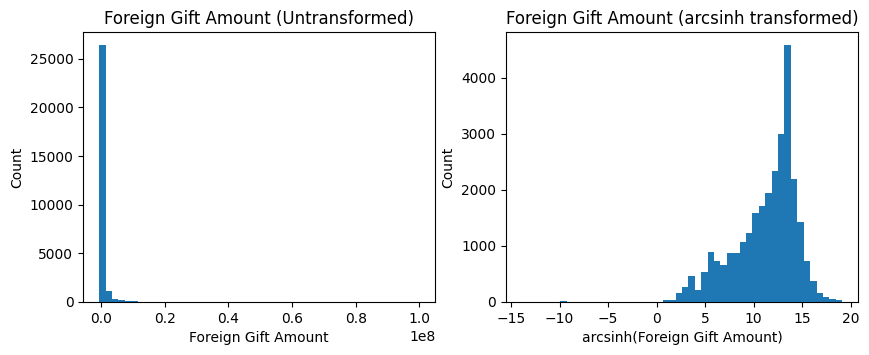

In [95]:
# 2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.


# Make an untransformed histogram
fig, axes = plt.subplots(1, 2, figsize = (10, 3.5))
df["Foreign Gift Amount"].hist(bins = 50, grid = False, ax = axes[0])
axes[0].set(title = "Foreign Gift Amount (Untransformed)", xlabel = "Foreign Gift Amount", ylabel = "Count")

# In the untransformed histogram, the data appears to have a long, right-tail distribution, with extremely high counts
# on the low end and extremely low counts on the high end. This indicates that the vast majority of donations fall
# under 1e7 dollars, but there are some extremely large donations that are less visible


# Make an arcsinh transformed histogram
df["Foreign Gift Amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["Foreign Gift Amount_arcsinh"].hist(bins = 50, grid = False, ax = axes[1])
axes[1].set(title = "Foreign Gift Amount (arcsinh transformed)", xlabel = "arcsinh(Foreign Gift Amount)", ylabel = "Count")

# The arcsinh transformed data (not part of the instructions, but I did it anyways) makes the data appear to have a left
# tailed distribution, but this is an artifact of the transformation. What it does show is that there appear to be some
# negative values, which indicate that the data probably should have been cleaned because negative donations are not plausible
# values in this case, and should be removed prior to any real analysis.

plt.show

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

proportions of each gift type:
61.21% are contracts
38.75% are monetary
0.04% are real estate


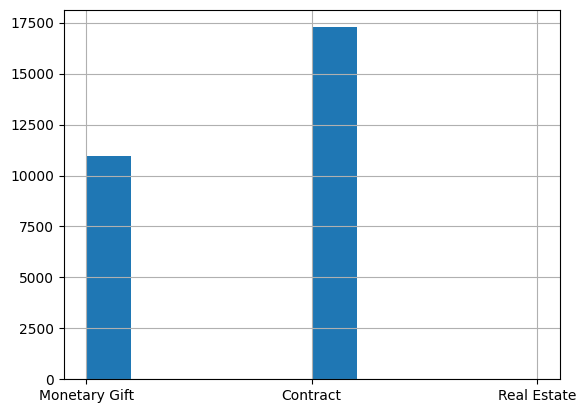

In [96]:
# 3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
df["Gift Type"].hist()
print(df["Gift Type"].value_counts())

# 17274 + 10936 + 11 = 28221 total gifts
# 61.21% are contracts
# 38.75% are monetary
# 0.04% are real estate
print("\nproportions of each gift type:\n61.21% are contracts\n38.75% are monetary\n0.04% are real estate")

c:\Users\micai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


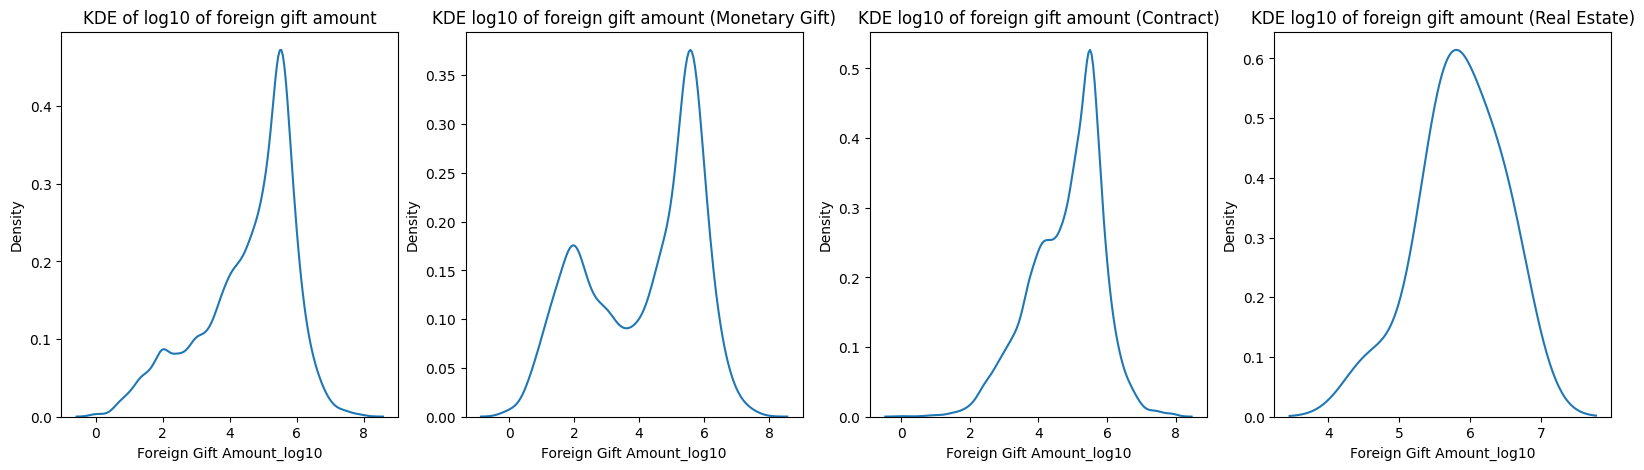

In [97]:
# 4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
import seaborn as sns


# axes for the plots to go on
fig, axes = plt.subplots(1, 4, figsize = (20, 5))


df["Foreign Gift Amount_log10"] = np.log10(df["Foreign Gift Amount"])

# KDE plot of the log10 of the foreign gift amount
sns.kdeplot(x=df["Foreign Gift Amount_log10"], bw_method="silverman", label = "Kernel Density Estimate", ax=axes[0])
axes[0].set(title = "KDE of log10 of foreign gift amount" )

# KDE plot of the log10 of the foreign gift amount conditional on gift type
# loop iterates through
axes_index = 1
for gift_type in df["Gift Type"].unique():
    df_subset = df[df["Gift Type"] == gift_type]
    sns.kdeplot(x=df_subset["Foreign Gift Amount_log10"], bw_method="silverman", label = "Kernel Density Estimate", ax=axes[axes_index])
    axes[axes_index].set(title = f"KDE log10 of foreign gift amount ({gift_type})")
    axes_index+=1


# I note that there appears to be a somewhat bimodal distribution in the overall KDE which is more clearly visible in the monetary gifts category.The contracts 
# category also has a bump which may indicate a slight bimodality (it looks like  a much smaller gaussian distribution overlaid at that point than in the
# monetary gifts category which looks like two pretty seperated gaussian distributions). Some of the artifacts visible in the overall category are visible as
# structures in the subcategories. Each one also appears to peak around log_10(amount) ~= 6, which is $1E6. These visualizations seem to corroborate with the
# extra visualization I did earlier with the arcsinh transformed data.
    

    

In [ ]:
# 5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

# prints the top 15 of the descending-sorted value counts (i.e. the number of times a country appears)
print(f"top 15 countires in terms of number of gifts given:\n{df["Country of Giftor"].value_counts().sort_values(ascending=False).head(15)}")

# top 15 countires in terms of number of gifts given:
# Country of Giftor
# ENGLAND            3655
# CHINA              2461
# CANADA             2344
# JAPAN              1896
# SWITZERLAND        1676
# SAUDI ARABIA       1610
# FRANCE             1437
# GERMANY            1394
# HONG KONG          1080
# SOUTH KOREA         811
# QATAR               693
# THE NETHERLANDS     512
# KOREA               452
# INDIA               434
# TAIWAN              381

# print the top 15 of the countries by the amount given (I spent way too long figuring out how to do this in a single line)
# groups the data, gets the max of each group, sorts them by the amount, and pulls the top 15 of the relevant columns
print(f"top 15 countires in terms of number of the amount given:\n{df.groupby(["Country of Giftor"], as_index=False).max().sort_values(by="Foreign Gift Amount", ascending = False)[["Country of Giftor", "Foreign Gift Amount"]].head(15)}")

# top 15 countires in terms of number of the amount given:
#         Country of Giftor  Foreign Gift Amount
# 6               AUSTRALIA             99999999
# 114                 QATAR             99999999
# 15                BERMUDA             75000000
# 136              THAILAND             67700000
# 26                 CANADA             48842186
# 58              HONG KONG             47670277
# 93                 MONACO             47600000
# 144  UNITED ARAB EMIRATES             43021197
# 118          SAUDI ARABIA             43000000
# 122             SINGAPORE             40000000
# 64                   IRAQ             39108635
# 61                  INDIA             38000000
# 30                  CHINA             35000000
# 43                ENGLAND             33880638
# 49                GERMANY             33044704




top 15 countires in terms of number of gifts given:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
top 15 countires in terms of number of the amount given:
        Country of Giftor  Foreign Gift Amount
6               AUSTRALIA             99999999
114                 QATAR             99999999
15                BERMUDA             75000000
136              THAILAND             67700000
26                 CANADA             48842186
58              HONG KONG             47670277
93                 MONACO             47600000
144  UNITED ARAB EMIRATES             43021197
118          SAUDI ARABIA             43000000
122             S

In [99]:
# 6. Which giftors provide the most money, in total?

print(f"top 15 countires in terms of number of total money given:\n{df.groupby("Country of Giftor")['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)}")

# top 15 countires in terms of number of total money given:
# Country of Giftor
# QATAR                   2706240869
# ENGLAND                 1464906771
# CHINA                   1237952112
# SAUDI ARABIA            1065205930
# BERMUDA                  899593972
# CANADA                   898160656
# HONG KONG                887402529
# JAPAN                    655954776
# SWITZERLAND              619899445
# INDIA                    539556490
# GERMANY                  442475605
# UNITED ARAB EMIRATES     431396357
# FRANCE                   405839396
# SINGAPORE                401157692
# AUSTRALIA                248409202


top 15 countires in terms of number of total money given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** e55c3defbdfcddb76bcb471714998b99f584f2cf
- **AI tool and model used:** GitHub Copilot on VS Code (GPT 5.6 Luna)

### *Prompts used

1. Look at my first python cell and list a couple of improvements which would better fulfill the task "Load the `./data/ForeignGifts_edu.csv` dataset.". 
2. Look at my second python cell and list a couple of improvements which would better fulfill the task "For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings."
3. Look at my third python cell and list a couple of improvements which would better fulfill the task "For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?"
4. Look at my fourth python cell and list a couple of improvements which would better fulfill the task "Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?"
5. Look at my fifth python cell and list a couple of improvements which would better fulfill the task "What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?"
6. Look at my sixth python cell and list a couple of improvements which would better fulfill the task "Which giftors provide the most money, in total?"

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]
# Prompt 1 ===========================================

I’ll inspect the notebook’s first code cell and its nearby task wording, then point out two concrete improvements to the dataset-loading step.



Retrieving Notebook summary.

The notebook’s first executable cell is the code cell at lines 51–68; the preceding markdown appears to contain the assignment prompt. I’m reading that exact slice now so the suggestions match the requested wording and the existing code.

Read , lines 44 to 70

Read 

Your first cell already loads the dataset correctly. Two improvements would make it better fulfill the task:

1. Use a clearly named file path that matches the assignment exactly:
   ```python
   csv_path = Path("./data/ForeignGifts_edu.csv")
   df = pd.read_csv(csv_path)
   ```

2. Confirm that the dataset loaded successfully by inspecting its structure:
   ```python
   print(df.shape)
   display(df.head())
   df.info()
   ```

You could also remove the unused `numpy` and `matplotlib` imports from this loading cell; they belong in later analysis or visualization cells.



# Prompt 2 ===========================================

I’ll refresh the notebook summary, identify the second Python cell by its visible cell order, and inspect that cell’s code and output so the improvements address both the histogram and the written interpretation.

Retrieving Notebook summary.

The second Python cell is the histogram cell at lines 71–94, and it currently produces both an original-scale and an extra arcsinh-transformed plot. I’m checking its exact output next, especially whether the written findings are supported by the plotted data.

Read , lines 71 to 94

Read output of 
Completed with input: {
  "filePath": "c:\\Users\\micai\\OneDrive - University of Virginia\\Documents\\GitHub\\A02-eda-and-visualization\\notebook.ipynb",
  "cellId": "#VSC-575f0337"
}

In the second Python cell, two improvements would better fulfill the task:

1. **Call `plt.show()` correctly.** The cell currently uses `plt.show`, which only displays the function object. Change it to:
   ```python
   plt.show()
   ```

2. **Support the description with summary statistics.** In addition to the histogram, report values such as the minimum, median, mean, maximum, and percentage of negative amounts:
   ```python
   df["Foreign Gift Amount"].describe()
   (df["Foreign Gift Amount"] < 0).mean() * 100
   ```
   This would let you substantiate claims about right skew, extreme values, and implausible negative gifts rather than relying only on visual interpretation.

The arcsinh histogram is useful for revealing the distribution, but it is extra relative to the prompt. If retained, explain why it is used and label it as a supplemental view in `notebook.ipynb:71-94`.

# Prompt 3 ===========================================

I’ll verify the current third Python cell and its visible output, then focus the suggestions on accurate proportions and a clearer categorical summary.

Retrieving Notebook summary.

Read , lines 97 to 105

In the third Python cell, two improvements would better fulfill the task:

1. **Calculate proportions programmatically** instead of hard-coding percentages:
   ```python
   gift_proportions = df["Gift Type"].value_counts(normalize=True).mul(100).round(2)
   print(gift_proportions)
   ```

2. **Use a bar chart or a labeled value-counts table** because `Gift Type` is categorical:
   ```python
   counts = df["Gift Type"].value_counts()

   counts.plot(kind="bar", title="Number of Gifts by Type")
   plt.xlabel("Gift Type")
   plt.ylabel("Number of Gifts")
   plt.xticks(rotation=0)
   plt.show()
   ```

This would make the category comparisons clearer and ensure the reported percentages automatically stay consistent with the dataset. See `notebook.ipynb:97-105`.


# Prompt 4 ===========================================

I’ll refresh the notebook structure and inspect the fourth Python cell’s current KDE code, including how it handles the logarithm and conditional plots.

Retrieving Notebook summary.

Read , lines 108 to 139

In the fourth Python cell, two improvements would better fulfill the task:

1. **Handle nonpositive amounts before taking the logarithm.** `np.log10()` is undefined for zero and negative values, which can produce `NaN` values and warnings. Filter them explicitly:
   ```python
   positive_gifts = df[df["Foreign Gift Amount"] > 0].copy()
   positive_gifts["amount_log10"] = np.log10(
       positive_gifts["Foreign Gift Amount"]
   )
   ```

2. **Make the conditional KDE plots more robust and comparable.** The code assumes there will always be exactly three gift types by creating four axes. Instead, create axes based on the actual categories, add clear labels, and use consistent x-axis limits. Also call `plt.tight_layout()` and `plt.show()` so the plots render cleanly.

The interpretation should also be written as a Markdown explanation rather than only code comments, and it should connect specific patterns in the overall plot to the corresponding gift-type plots. See `notebook.ipynb:108-139`.


# Prompt 5 ===========================================

I’ll inspect the fifth Python cell’s current aggregation logic, focusing on whether it computes gift counts and total amounts correctly and distinctly.

Read , lines 142 to 188

In the fifth Python cell, two important improvements would better fulfill the task:

1. **Use `sum()` instead of `max()` for the amount ranking.** The current code ranks countries by their single largest gift, but the task asks for the total amount given by each country:
   ```python
   top_countries_by_amount = (
       df.groupby("Country of Giftor")["Foreign Gift Amount"]
       .sum()
       .sort_values(ascending=False)
       .head(15)
   )
   print(top_countries_by_amount)
   ```

2. **Compute both rankings programmatically and label them clearly**, rather than including hard-coded results in comments:
   ```python
   top_countries_by_count = (
       df["Country of Giftor"]
       .value_counts()
       .head(15)
   )

   print("Top 15 countries by number of gifts:")
   print(top_countries_by_count)

   print("\nTop 15 countries by total amount given:")
   print(top_countries_by_amount)
   ```

This ensures the results remain accurate if the dataset changes. The current amount calculation is the main issue because `.max()` answers a different question. See `notebook.ipynb:142-188`.

# Prompt 6 ===========================================

The sixth Python cell currently groups by country, so I’m checking the dataset’s column names to distinguish the actual giftor field from the country field before suggesting the fix.

Read , lines 1 to 3

In the sixth Python cell, two improvements would better fulfill the task:

1. **Group by `Giftor Name`, not `Country of Giftor`.** The current code reports which countries provide the most money, not which giftors:
   ```python
   top_giftors = (
       df.dropna(subset=["Giftor Name"])
       .groupby("Giftor Name")["Foreign Gift Amount"]
       .sum()
       .sort_values(ascending=False)
       .head(15)
   )

   print("Top giftors by total amount given:")
   print(top_giftors)
   ```

2. **Compute the results dynamically and clarify missing names.** The hard-coded comments list country totals and may become inaccurate if the dataset changes. Excluding missing `Giftor Name` values makes clear that only identified giftors are ranked.

The main issue is that the current cell answers a country-level question rather than the requested giftor-level question. See `notebook.ipynb:191-214`.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| Use a clearly named file path that matches the assignment exactly: | reject | I already did this better |
| Confirm that the dataset loaded successfully by inspecting its structure: | Accept| sure, why not |
|Call plt.show() correctly. The cell currently uses plt.show, which only displays the function object. Change it to:plt.show()| Accept | Sure |
|Support the description with summary statistics. In addition to the histogram, report values such as the minimum, median, mean, maximum, and percentage of negative amounts: | accept | does help with EDA better, even if it's not an assigned task |
| Calculate proportions programmatically instead of hard-coding percentages:| accept | helps make this code more applicable to further EDA |
| Use a bar chart or a labeled value-counts table because Gift Type is categorical: | reject | does not help and is not in line with instructions |
| Handle nonpositive amounts before taking the logarithm. np.log10() is undefined for zero and negative values, which can produce NaN values and warnings. Filter them explicitly: | reject | not relevant here |
| Make the conditional KDE plots more robust and comparable. The code assumes there will always be exactly three gift types by creating four axes. Instead, create axes based on the actual categories, add clear labels, and use consistent x-axis limits. Also call plt.tight_layout() and plt.show() so the plots render cleanly.| rect | not relevant here since this is exploratory |
| Use sum() instead of max() for the amount ranking. The current code ranks countries by their single largest gift, but the task asks for the total amount given by each country: | reject | I similarly misunderstood the question, but in the context of the next question, it doesn't make sense |
| Compute both rankings programmatically and label them clearly, rather than including hard-coded results in comments: | reject | I'm already doing this |
 Group by Giftor Name, not Country of Giftor. The current code reports which countries provide the most money, not which giftors: | accept | this is correct. I misunderstood the original question apparently |
| Compute the results dynamically and clarify missing names. The hard-coded comments list country totals and may become inaccurate if the dataset changes. Excluding missing Giftor Name values makes clear that only identified giftors are ranked. | reject | I don't really care to change the comments for this assignment |



### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [104]:
# Your Phase 2 solution to the problem goes here.

# 1. Load the `./data/ForeignGifts_edu.csv` dataset.

import numpy as np
import pandas as pd
from pathlib import Path # object-oriented file path handling
import matplotlib.pyplot as plt

DATA_DIR = Path("data") # define a variable for the data directory

df = pd.read_csv(DATA_DIR / "ForeignGifts_edu.csv") # load the .csv

print(df.shape)
display(df.head())
df.info()

# transform to floating point 64
# df["Foreign Gift Amount"] = pd.to_numeric(df["Foreign Gift Amount"])

(28221, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          28221 non-null  int64
 1   OPEID                       28221 non-null  int64
 2   Institution Name            28221 non-null  str  
 3   City                        28221 non-null  str  
 4   State                       28221 non-null  str  
 5   Foreign Gift Received Date  28221 non-null  int64
 6   Foreign Gift Amount         28221 non-null  int64
 7   Gift Type                   28221 non-null  str  
 8   Country of Giftor           28221 non-null  str  
 9   Giftor Name                 24470 non-null  str  
dtypes: int64(4), str(6)
memory usage: 2.2 MB


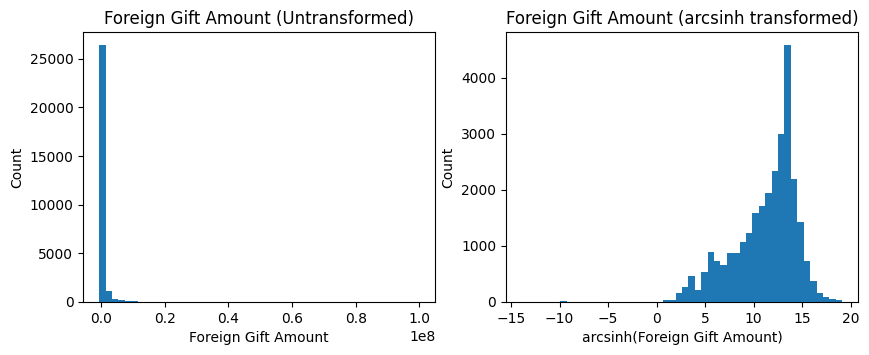

np.float64(0.08504305304560433)

In [105]:
# 2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.


# Make an untransformed histogram
fig, axes = plt.subplots(1, 2, figsize = (10, 3.5))
df["Foreign Gift Amount"].hist(bins = 50, grid = False, ax = axes[0])
axes[0].set(title = "Foreign Gift Amount (Untransformed)", xlabel = "Foreign Gift Amount", ylabel = "Count")

# In the untransformed histogram, the data appears to have a long, right-tail distribution, with extremely high counts
# on the low end and extremely low counts on the high end. This indicates that the vast majority of donations fall
# under 1e7 dollars, but there are some extremely large donations that are less visible


# Make an arcsinh transformed histogram
df["Foreign Gift Amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["Foreign Gift Amount_arcsinh"].hist(bins = 50, grid = False, ax = axes[1])
axes[1].set(title = "Foreign Gift Amount (arcsinh transformed)", xlabel = "arcsinh(Foreign Gift Amount)", ylabel = "Count")

# The arcsinh transformed data (not part of the instructions, but I did it anyways) makes the data appear to have a left
# tailed distribution, but this is an artifact of the transformation. What it does show is that there appear to be some
# negative values, which indicate that the data probably should have been cleaned because negative donations are not plausible
# values in this case, and should be removed prior to any real analysis.

plt.show()
df["Foreign Gift Amount"].describe()
(df["Foreign Gift Amount"] < 0).mean() * 100

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         61.21
Monetary Gift    38.75
Real Estate       0.04
Name: proportion, dtype: float64


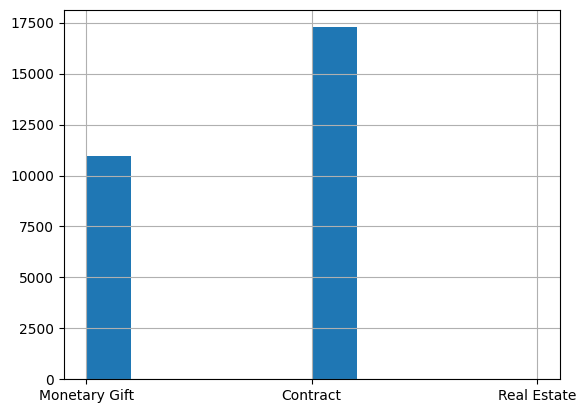

In [106]:
# 3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
df["Gift Type"].hist()
print(df["Gift Type"].value_counts())

# 17274 + 10936 + 11 = 28221 total gifts
# 61.21% are contracts
# 38.75% are monetary
# 0.04% are real estate

gift_proportions = df["Gift Type"].value_counts(normalize=True).mul(100).round(2)
print(gift_proportions)

c:\Users\micai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


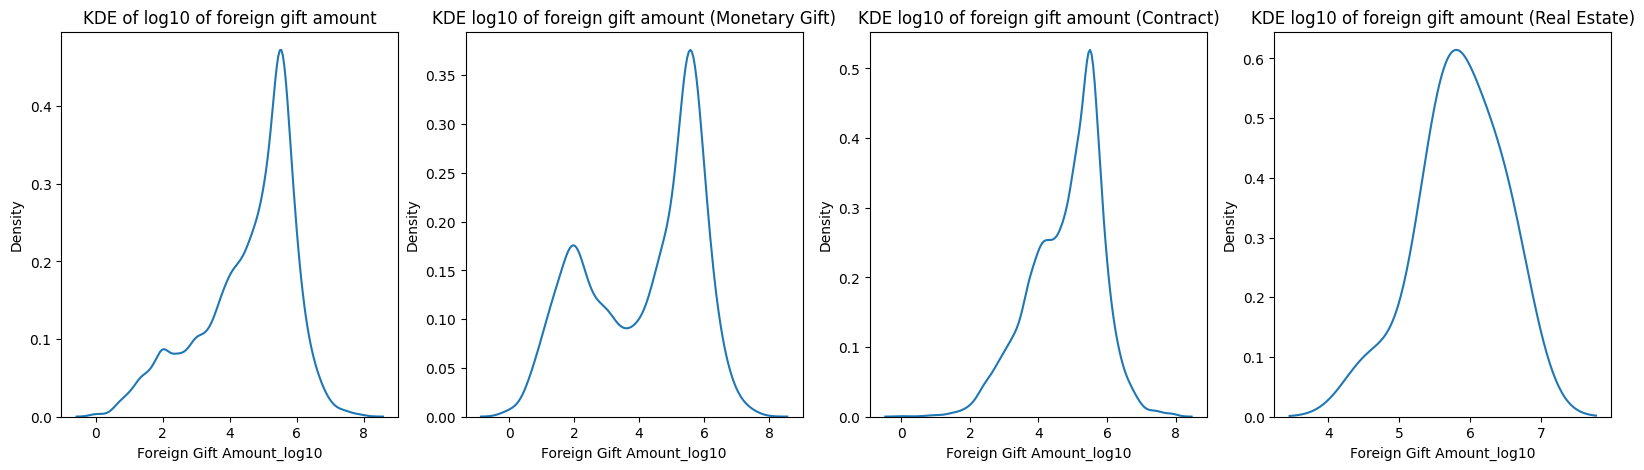

In [107]:
# 4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
import seaborn as sns


# axes for the plots to go on
fig, axes = plt.subplots(1, 4, figsize = (20, 5))


df["Foreign Gift Amount_log10"] = np.log10(df["Foreign Gift Amount"])

# KDE plot of the log10 of the foreign gift amount
sns.kdeplot(x=df["Foreign Gift Amount_log10"], bw_method="silverman", label = "Kernel Density Estimate", ax=axes[0])
axes[0].set(title = "KDE of log10 of foreign gift amount" )

# KDE plot of the log10 of the foreign gift amount conditional on gift type
# loop iterates through
axes_index = 1
for gift_type in df["Gift Type"].unique():
    df_subset = df[df["Gift Type"] == gift_type]
    sns.kdeplot(x=df_subset["Foreign Gift Amount_log10"], bw_method="silverman", label = "Kernel Density Estimate", ax=axes[axes_index])
    axes[axes_index].set(title = f"KDE log10 of foreign gift amount ({gift_type})")
    axes_index+=1


# I note that there appears to be a somewhat bimodal distribution in the overall KDE which is more clearly visible in the monetary gifts category.The contracts 
# category also has a bump which may indicate a slight bimodality (it looks like  a much smaller gaussian distribution overlaid at that point than in the
# monetary gifts category which looks like two pretty seperated gaussian distributions). Some of the artifacts visible in the overall category are visible as
# structures in the subcategories. Each one also appears to peak around log_10(amount) ~= 6, which is $1E6. These visualizations seem to corroborate with the
# extra visualization I did earlier with the arcsinh transformed data.
    

    

In [108]:
# 5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

# prints the top 15 of the descending-sorted value counts (i.e. the number of times a country appears)
print(f"top 15 countires in terms of number of gifts given:\n{df["Country of Giftor"].value_counts().sort_values(ascending=False).head(15)}")

# top 15 countires in terms of number of gifts given:
# Country of Giftor
# ENGLAND            3655
# CHINA              2461
# CANADA             2344
# JAPAN              1896
# SWITZERLAND        1676
# SAUDI ARABIA       1610
# FRANCE             1437
# GERMANY            1394
# HONG KONG          1080
# SOUTH KOREA         811
# QATAR               693
# THE NETHERLANDS     512
# KOREA               452
# INDIA               434
# TAIWAN              381

# print the top 15 of the countries by the amount given (I spent way too long figuring out how to do this in a single line)
# groups the data, gets the max of each group, sorts them by the amount, and pulls the top 15 of the relevant columns


print(f"top 15 countires in terms of number of the amount given:\n{df.groupby(["Country of Giftor"], as_index=False).max().sort_values(by="Foreign Gift Amount", ascending = False)[["Country of Giftor", "Foreign Gift Amount"]].head(15)}")

# top 15 countires in terms of number of the amount given:
#         Country of Giftor  Foreign Gift Amount
# 6               AUSTRALIA             99999999
# 114                 QATAR             99999999
# 15                BERMUDA             75000000
# 136              THAILAND             67700000
# 26                 CANADA             48842186
# 58              HONG KONG             47670277
# 93                 MONACO             47600000
# 144  UNITED ARAB EMIRATES             43021197
# 118          SAUDI ARABIA             43000000
# 122             SINGAPORE             40000000
# 64                   IRAQ             39108635
# 61                  INDIA             38000000
# 30                  CHINA             35000000
# 43                ENGLAND             33880638
# 49                GERMANY             33044704




top 15 countires in terms of number of gifts given:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
top 15 countires in terms of number of the amount given:
        Country of Giftor  Foreign Gift Amount
6               AUSTRALIA             99999999
114                 QATAR             99999999
15                BERMUDA             75000000
136              THAILAND             67700000
26                 CANADA             48842186
58              HONG KONG             47670277
93                 MONACO             47600000
144  UNITED ARAB EMIRATES             43021197
118          SAUDI ARABIA             43000000
122             S

In [ ]:
# 6. Which giftors provide the most money, in total?

# print(f"top 15 countires in terms of number of total money given:\n{df.groupby("Country of Giftor")['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)}")
top_giftors = (
    df.dropna(subset=["Giftor Name"])
    .groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("Top giftors by total amount given:")
print(top_giftors)



Top giftors by total amount given:
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


### *Reflection on AI assistance
In your own words without generative AI.


Overall, the AI really was not that helpful. It didn't correct very many meaningful things and made at least one mistake with misunderstanding a question, but it also corrected one of my mistakes that I made. I think that it was overall helpful as a checking tool, but it was rather arduous to have to go through and list out every prompt and reasoning for why to accept or reject the prompt. In other words, the documentation of the AI makes using the AI not worth it. Because the vast majority of my code was well-written and correct, the agent seemed to get caught up on really small, essentially meaningless details, such as my comments I included for the sake of the assignment. However, it did catch my main mistake I made in the assignment (which I am kicking myself over a bit). I think that the utility of the AI is for convenience, and when that convenience is removed by extensive documentation (essentially paperwork), it incentivises writing the code correctly in the first place and adds an additional bottleneck to using the agent.
